# Sentiment Analysis

## Importing Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re # Regex Library 
import nltk # Natural Language Tool Kit Library
from nltk.tokenize import word_tokenize # Tokenization
from nltk.corpus import stopwords # Stopwords
from nltk.stem import PorterStemmer # Stemming
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF Vectorization

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Fetching Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

## Collecting Basic Info

In [3]:
print(df.shape)
df.info()
df.head(5)

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Cleaning

### 1. Check for Missing Values

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_%": df.isnull().sum()/len(df)
})

missing_val = missing[missing["missing_count"]>0]

print("No Missing Values found!") if missing_val.empty else missing_val

No Missing Values found!


### 2. Check for Duplicate Values

In [5]:
duplicates = df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df[df.duplicated()].drop_duplicates()
    print("Rows removed: ", duplicates)
    print("Old Shape:", df.shape)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("New Shape:", df.shape)
else:
    print("No Duplicates found!")

Rows removed:  418
Old Shape: (50000, 2)
New Shape: (49582, 2)


### 3. Fixing Column names & data

In [6]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

### 4. Identifying various Sentiments in Categorical Column

In [7]:
print("Column: sentiment")
print("Total Unique Sentiments:", df["sentiment"].nunique())
df["sentiment"].value_counts(normalize=True)*100

Column: sentiment
Total Unique Sentiments: 2


sentiment
positive    50.187568
negative    49.812432
Name: proportion, dtype: float64

## Data Pre-processing

### 1. Converting Reviews to lowercase

In [8]:
df["review"] = df["review"].str.lower()

### 2. Removing URLs from Reviews

In [9]:
def remove_urls(text):
    text = re.sub(r"http\S+", "", text) # pattern to be replaced, replacement, To be applied on
    # \S+ : represents all the characters. It means include all the characters, till you find some space
    return text

df["review"] = df["review"].apply(remove_urls)

### 3. Removing Punctuations from Reviews

In [10]:
def remove_punctuations(text):
    text = re.sub(r"[^A-Za-z0-9\s]", "", text) # punctuations are everything apart from A-Z, a-z, " " (space) or \s
    # ^ means everything apart from what we mentioned
    return text

df["review"] = df["review"].apply(remove_punctuations)

### 4. Removing HTML Tags from Reviews

In [11]:
def remove_html_tags(text):
    text = re.sub(r"<.*?>", "", text) 
    # <.> : . (dot) represents any tag in between <>
    # * : represents 0 or more characters
    # ? : remove in non-greedy manner, means till it finds the closing tag
    
    return text

df["review"] = df["review"].apply(remove_html_tags)

### 5. Removing Stopwords/Fillers from Reviews

In [12]:
def remove_stopwords(text):
    tokens = word_tokenize(text) # Tokenization
    stop_words = stopwords.words("english")

    for word in tokens:
        if word in stop_words:
            text.replace(word, "")
    return text

df["review"] = df["review"].apply(remove_stopwords)

In [13]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


### 6. Stemming => Bringing words to their Base form

In [14]:
def stemming(text):
    ps = PorterStemmer()
    stemmed_words = []
    tokens = word_tokenize(text)
    for token in tokens:
        stemmed_token = ps.stem(token) # Stemming the tokens
        stemmed_words.append(stemmed_token)
    return " ".join(stemmed_words)

df["review"] = df["review"].apply(stemming)

In [15]:
df.head()

,review,sentiment
0,one of the other review ha mention that after ...,positive
1,a wonder littl product br br the film techniqu...,positive
2,i thought thi wa a wonder way to spend time on...,positive
3,basic there a famili where a littl boy jake th...,negative
4,petter mattei love in the time of money is a v...,positive


### 7. Data Encoding

In [16]:
le = LabelEncoder()

df["sentiment"] = le.fit_transform(df["sentiment"])
y = df["sentiment"]
print(le.classes_)

['negative' 'positive']


### 8. TF-IDF Vectorization => Converting text to numbers

In [17]:
tf = TfidfVectorizer(max_features=5000) # We are choosing top 5k words, else it will be a huge matrix for our system to process
X = tf.fit_transform(df["review"])

In [18]:
print(X)
# We have 5.8~6 million elements in our matrix, even after applying max_features=5000 toop words
# It is important to use max_features, as it will be impossible for our normal CPU systems to handle around 1 billion elements.
# Hence, it's important to limit the data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5871102 stored elements and shape (49582, 5000)>
  Coords	Values
  (0, 3123)	0.02032251735685024
  (0, 3098)	0.09542098470744526
  (0, 4441)	0.20903467205715237
  (0, 3152)	0.057164905655617715
  (0, 3689)	0.04795018941759714
  (0, 2025)	0.024837126680226217
  (0, 2809)	0.05093623457657249
  (0, 4439)	0.06274954229236089
  (0, 164)	0.032260181258981106
  (0, 4821)	0.07851591273828991
  (0, 2475)	0.04850405470299644
  (0, 3185)	0.43216782713328356
  (0, 1535)	0.10274122058172444
  (0, 4987)	0.05287089753313154
  (0, 444)	0.05711365014241208
  (0, 2179)	0.07161368973329611
  (0, 4456)	0.024446041394784856
  (0, 302)	0.041296577361905513
  (0, 3712)	0.08249984253761973
  (0, 325)	0.07507443472841555
  (0, 4461)	0.04274859304710011
  (0, 2386)	0.1295866356729789
  (0, 1583)	0.05594527309388424
  (0, 4864)	0.049933268194460693
  (0, 2053)	0.04118502050404425
  :	:
  (49581, 2285)	0.09370049477083149
  (49581, 1655)	0.165150657435

## Train_Test_Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split( # (scipy)sparse_matrix, (scipy)sparse_matrix, pd_series, pd_series
    X, y, test_size=0.2, random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (39665, 5000)
X_test Shape: (9917, 5000)


In [20]:
X_train = X_train.toarray() # np_array
X_test = X_test.toarray() # np_array

## Creating Dataset

In [21]:
train_set = TensorDataset(
    torch.from_numpy(X_train).float(), # Directly converted to Tensor
    torch.from_numpy(y_train.values).float() # Directly converted to Tensor
)

test_set = TensorDataset(
    torch.from_numpy(X_test).float(), # Directly converted to Tensor
    torch.from_numpy(y_test.values).float() # Directly converted to Tensor
)

## Creating Dataloaders

In [22]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=True) # in test_loader we have kept shuffle=True, as it is huge

## Define RNN Model => Many to One Architecture

In [23]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # RNN Layer
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

        # Fully COnnected Layer
        self.fc = nn.Linear(hidden_size, 1)

    # Forward Propagation
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size) # Optional => shape(num of layers, batch_size, hidden_size)

        out,_ = self.rnn(x, h0) 
        # 1st val = hidden state of all the timesteps (batch, seq_len, hidden_size)
        # 2nd val = final hidden state of last timestep

        out = self.fc(out)[:, -1, :]
        return out

In [24]:
input_size = X_train.shape[1]
model = RNN(input_size)

criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters())

## Training the RNN Model

In [25]:
epochs = 10
train_losses = []
valid_losses = []
best_val = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for Xb,yb in train_loader:
        optimizer.zero_grad()

        Xb = Xb.unsqueeze(1) # Adds one dimension. So, now it's 3D
        outputs = model(Xb) # Dimension: (batch_size,1)

        outputs = torch.sigmoid(outputs.squeeze()) # We want Dimension: (batch_size,). squeeze() reduces one dimension. We got probability

        loss = criterion(outputs, yb) # compute loss
        loss.backward() # Back Propagation
        optimizer.step() # Update parameters

        running_loss += loss.item()

    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_valid_loss = 0.0

    with torch.no_grad():
        for Xb,yb in test_loader:
            Xb = Xb.unsqueeze(1)
            
            outputs = model(Xb)
            outputs = torch.sigmoid(outputs.squeeze())
            loss = criterion(outputs, yb)
            
            running_valid_loss += loss.item()
            
    epoch_valid_loss = running_valid_loss/len(test_loader)
    valid_losses.append(epoch_valid_loss)

    # Saving & Loading the best model
    if epoch_valid_loss < best_val:
        best_val = epoch_valid_loss
        torch.save(model.state_dict(), "best_RNN_model.pt")

    print(f"Epoch: {epoch+1}/{epochs} => Train Loss = {epoch_train_loss} => Valid Loss = {epoch_valid_loss}")

Epoch: 1/10 => Train Loss = 0.34244358294433164 => Valid Loss = 0.2641877556039441
Epoch: 2/10 => Train Loss = 0.2265908123144219 => Valid Loss = 0.27241390309026164
Epoch: 3/10 => Train Loss = 0.21062497912395384 => Valid Loss = 0.280341937753462
Epoch: 4/10 => Train Loss = 0.20329047309294823 => Valid Loss = 0.291899368070787
Epoch: 5/10 => Train Loss = 0.1984718729231146 => Valid Loss = 0.29868851717441314
Epoch: 6/10 => Train Loss = 0.19430908703755947 => Valid Loss = 0.30396704476687214
Epoch: 7/10 => Train Loss = 0.1926987652636824 => Valid Loss = 0.3039934519798525
Epoch: 8/10 => Train Loss = 0.1909581670357335 => Valid Loss = 0.3103520816372287
Epoch: 9/10 => Train Loss = 0.18904865277149985 => Valid Loss = 0.3139507997901209
Epoch: 10/10 => Train Loss = 0.1876722943518431 => Valid Loss = 0.3210246383182464


## Load the Best Model

In [26]:
model.load_state_dict(torch.load("best_RNN_model.pt"))

<All keys matched successfully>

In [27]:
idx = np.argmin(valid_losses)
print("Best Model Parameters")
print("Epoch:", idx+1)
print("Training Loss:", train_losses[idx])
print("Validation Loss:", valid_losses[idx])

Best Model Parameters
Epoch: 1
Training Loss: 0.34244358294433164
Validation Loss: 0.2641877556039441


## Visualising Losses

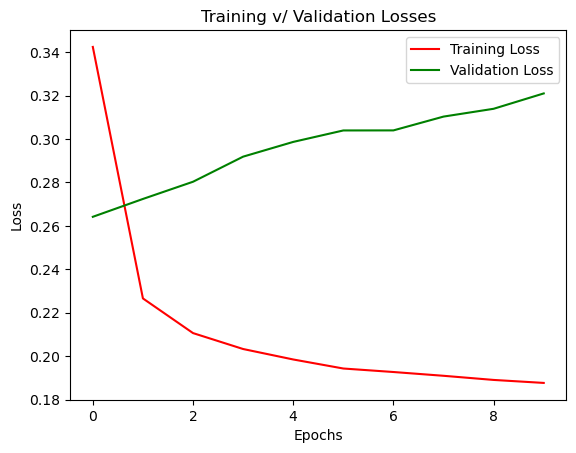

In [28]:
loss_df = pd.DataFrame({
    "Epoch": range(epochs),
    "Training_Loss": train_losses,
    "Validation_Loss": valid_losses
})

sns.lineplot(
    data = loss_df,
    x = "Epoch",
    y = "Training_Loss",
    color = "red",
    label = "Training Loss"
)

sns.lineplot(
    data = loss_df,
    x = "Epoch",
    y = "Validation_Loss",
    color = "green",
    label = "Validation Loss"
)

plt.title("Training v/ Validation Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.savefig("loss_curve.png")
plt.show()

## Evaluating RNN Model

In [29]:
all_labels = []
all_preds = []

model.eval()

with torch.no_grad():
    correct_vals = 0
    tot_vals = 0

    for Xb,yb in test_loader:
        Xb = Xb.unsqueeze(1)

        outputs = model(Xb)
        predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()

        tot_vals += yb.size(0)
        correct_vals += (predicted == yb).sum().item()

        all_preds.extend(predicted.numpy())
        all_labels.extend(yb.numpy())

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels, 
    all_preds, 
    average="weighted"
)

recall = recall_score(
    all_labels, 
    all_preds, 
    average="weighted"
)

f1 = f1_score(
    all_labels, 
    all_preds, 
    average="weighted"
)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 88.99%
Precision: 0.8902
Recall: 0.8899
F1 Score: 0.8899


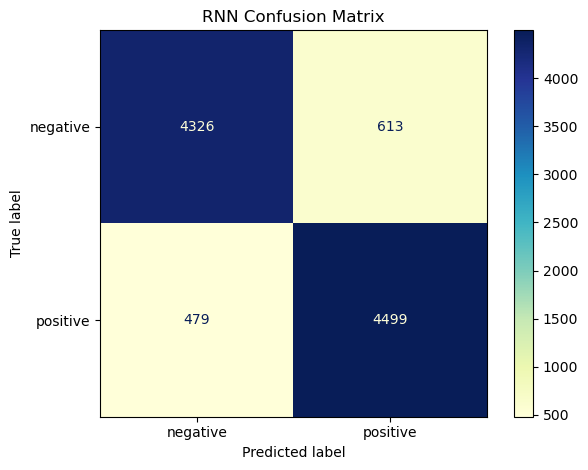

In [30]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

classes = le.classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="YlGnBu"
)

plt.title("RNN Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()